QUMDA

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit import QuantumRegister
from qiskit import ClassicalRegister
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate
from qiskit.providers.basic_provider import BasicProvider
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info.operators import Operator
import heapq
import os
from qiskit.visualization import plot_histogram

In [2]:
def OneMaxBS(CS, n, SelectedAmount):

  candidadatesValues = {}
  count = int(CS[0][0])
  pos = 0

  for i  in range(1, len(CS[0])):
    count += int(CS[0][i])
    if i % n == n -1:
      candidadatesValues[pos] = count
      pos+=1
      count = 0

  # Find the key with the largest amount of 1
  largest = heapq.nlargest(SelectedAmount, candidadatesValues, key=candidadatesValues.get)

  return largest



In [3]:
x = OneMaxBS(['110111'], 2, 2) #!!Delete
print(x)


[0, 2]


In [4]:
def LeadingOnesBS(CS, n, SelectedAmount):
  candidadatesValues = {}
  count = 0
  longcount = 0

  if int(CS[0][0]) == 1:
    longcount+=1
  else:
    count = longcount
    longcount = 0

  pos = 0

  for i  in range(1, len(CS[0])):
    if int(CS[0][i]) == 1:
      longcount+=1
    else:
      count = longcount
      longcount = 0

    if i % n == n - 1 :
      candidadatesValues[pos] = max(count, longcount)
      pos+=1
      count = 0
      longcount = 0


  # Find the key with the largest length of 1
  largest = heapq.nlargest(SelectedAmount, candidadatesValues, key=candidadatesValues.get)

  return largest

In [5]:
x = LeadingOnesBS(['011101010111'], 3, 2) #Delete 011101010111

In [6]:
def BinValuesBS(CS, n, SelectedAmount):
    candidadatesValues = {}
    index = n - 1
    count = int(CS[0][0]) * 2 ** index
    pos = 0

    for i  in range(1, len(CS[0])):
        index -= 1
        if index == -1 :
            index = n - 1

        count += int(CS[0][i]) * 2 ** index
        if i % n == n -1 :
            candidadatesValues[pos] = count
            pos+=1
            count = 0

    # Find the key with the biggest binary value
    largest = heapq.nlargest(SelectedAmount, candidadatesValues, key=candidadatesValues.get)

    return largest

In [7]:
x = BinValuesBS(['10111101'], 2, 2) #Delete
print(x)

[1, 2]


In [8]:
def combine(n):
    # Make diccionary
    combine = {}

    for i in range(2**n):
        combine[i] = format(i, f'0{n}b')

    return combine

In [9]:
def CreateProbabilityVector(n, SelectedAmount, BS):
    ST = [0.0] * n
    stSTR = ""
    # Accumulate sums for each bit position
    for i in range(n * SelectedAmount):
        ST[i % n] += int(BS[0][i])  # Convert binary character to integer

    ST = [x / float(SelectedAmount) for x in ST]

    #f = open("Results.txt", "a")
    #for i in range(n):
    #    stSTR += "Index " + str(i) + ":" + str(ST[i]) + "\n"
    #f.write("PV:\n" + stSTR)
    #f.write("\n")
    #f.close()
    return ST

In [10]:
def ImproveDiversity(ST):
    increment = 0.1

    # Update the probabilities
    for i in range(len(ST)):
        if ST[i] == 0.0:
            ST[i] = increment
    return ST

In [11]:
def SelectedCandidates(counts, PopulationAmount, n, ST, x):
    population = []
    value = 0.0
    index = 2
    candidates = heapq.nlargest(n**2, counts, key=counts.get)

    # Helper function to adjust a candidate according to ST
    def adjust_candidate(candidate, ST):
        adjusted = list(candidate)
        for i in range(len(ST)):
            if ST[i] == 1.0:
                adjusted[i] = '1'  # or any value matching the condition
            elif ST[i] == 0.0:
                adjusted[i] = '0'  # or any value matching the condition

        return ''.join(adjusted)

    # Helper function to check if two candidates are contrary
    # def are_contrary(candidate1, candidate2):
    #     return all(c1 != c2 for c1, c2 in zip(candidate1, candidate2))
    if x == 0:
        for candidate in candidates:
            population.append(candidate)
            if len(population) >= PopulationAmount:
                return population
    else:
        # Generate valid population based on ST
        for candidate in candidates:
            stCheck = True
            for i in range(len(ST)):
                value = ST[i]
                if (value == 1.0 or value == 0.0) and int(value) != int(candidate[i]):
                    stCheck = False
                    break
            if not stCheck:
                candidate = adjust_candidate(candidate, ST)
            population.append(candidate)

            if len(population) >= PopulationAmount:
                return population

    return population


In [12]:
def SelectedCandidates1(counts, PopulationAmount, n, ST):
    population = []
    value = 0.0

    candidates = heapq.nlargest(n**2, counts, key=counts.get)

    # Helper function to adjust a candidate according to ST
    def adjust_candidate(candidate, ST):
        adjusted = list(candidate)
        for i in range(len(ST)):
            if ST[i] == 1.0:
                adjusted[i] = '1'  # or any value matching the condition
            elif ST[i] == 0.0:
                adjusted[i] = str(candidate[i])  # or any value matching the condition

        return ''.join(adjusted)

    # Helper function to check if two candidates are contrary
    def are_contrary(candidate1, candidate2):
        return all(c1 != c2 for c1, c2 in zip(candidate1, candidate2))

    # Generate valid population based on ST

    for candidate in candidates:
        stCheck = True
        for i in range(len(ST)):
            value = ST[i]
            # (value == 1.0 or value == 0.0)
            if (value == 1.0 or value == 0.0) and int(value) != int(candidate[i]):
                stCheck = False
                break
        if not stCheck:
            candidate = adjust_candidate(candidate, ST)
        population.append(candidate)

        if len(population) >= PopulationAmount:
            return population


    return population

In [13]:
def SelectedPopulation(population):
    CS = []
    populationStr = ""
    csStr = ""
    j = 0
    for candidate in population:
        populationStr += "\n Cantidate" + str(j) + ":"
        j+=1
        populationStr += candidate
        csStr += candidate
    CS.append(csStr)
    return populationStr, CS

In [14]:
def getBS(CS, BS_index, n):
  bs_str = ''
  for i in range(n):
    bs_str += CS[0][n*BS_index + i]
  return bs_str

In [15]:
#TO DO: Check if achieve the conditions
def CheckConditions(CS, n, SelectedAmount, benchmark):
    BS = []
    BS_index = []
    bs_str = ''
    Conditions = True
    #if all(element == 1 for element in int(CS[0])) :
    #    return [], True

    #Best solution for OneMax, LeadingOnes and BinValues, a set of 1
    for i in (CS[0]):
        if i != '1':
            Conditions = False
            break

    if Conditions:
        return BS, Conditions


    match benchmark:
        case 0:
            BS_index = OneMaxBS(CS, n, SelectedAmount)
        case 1:
            BS_index = LeadingOnesBS(CS, n, SelectedAmount)
        case 2:
            BS_index = BinValuesBS(CS, n, SelectedAmount)
        case _:
            print("Error")

    for i in BS_index:
        bs_str += getBS(CS, i, n)

    BS.append(bs_str)

    return BS, Conditions

In [16]:
x, y = CheckConditions(['11111111'], 2, 2, 0)
print(x,y)
#print(CreateProbabilityVector(2, 2, x))


[] True


In [17]:
def WriteResults(x, n, bcombine, counts, PopulationAmount, ST):
    populationStr = ""
    CS = []

    f = open("Results.txt", "a")
    f.write(str(x) + " Generations: \n")
    #for i in range(2**n):
        #f.write("Value for " + bcombine[i] + ":" + str(counts.get(bcombine[i], 0)) + "\n")
    #f.write("\n")
    population = SelectedCandidates(counts, PopulationAmount, n, ST, x)
    populationStr, CS = SelectedPopulation(population)
    f.write("New population: " + populationStr +  "\n")
    f.write("\n")
    f.close()

    return CS

In [18]:
def Amplification(qc, n):
    number = 2/(2**n)
    IA2 = np.full((2 ** n, 2 ** n), number)
    for i in range(2 ** n):
        IA2[i, i] -= 1.
    gate1 = UnitaryGate(IA2, label=" -I + 2A")
    qc.unitary(IA2, qc.qubits[:n], label='Amplification')


In [19]:
#TO DO: Generated Population with normal distribution, Is not in this case !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
def GeneratedPopulation(qc, n):
    matrix = np.identity(2 ** n, dtype=complex)
    gate = UnitaryGate(matrix, label="Generated Population")
    qc.append(gate, qc.qubits[:n])

In [20]:
def NewPopulation(qc, n, ST, bcombine):
    for j in range(n):
        matrix = np.identity(2 ** n, dtype=complex)
        prob = ST[j]
        if prob != 0.5:
            #Calculate alpha and beta based on the Probability vector or state vector
            alpha = prob + np.sqrt(1 - prob**2) * 1j
            beta = 1 - prob + np.sqrt(1 - (1 - prob)**2) * 1j

            #if prob == 1.0:
            #    alpha = -1
            #    beta = 1

            for i in range(2**n):
                if bcombine[i][j] == '0':
                    matrix[i][i] = beta
                else:
                    matrix[i][i] = alpha

        gate = UnitaryGate(matrix, label="New Population: Index " + str(j))
        qc.append(gate, qc.qubits[:n])
        #Amplification(qc, n)

In [21]:
def BuildCircuit(n, ST, bcombine, generated):
    qc = QuantumCircuit(n, n)
    [qc.h(i) for i in range(n)]
    if (generated):
        NewPopulation(qc, n, ST, bcombine)
        Amplification(qc, n)
    else:
        GeneratedPopulation(qc, n)

    qc.measure(range(n), range(n))
    return qc

In [22]:
#CONSTANT

n = 6 #Length of the individual sample
PopulationAmount = 4 # Amount of individual sample
maxGenerations = 100 #QUMDA repetitions
ST = n * [0.5] #Probability vector
bcombine = combine(n)
#alpha_base = 0.8 + 0.6j # st
#beta_base = 0.2 + np.sqrt(1- 0.2**2) * 1j #This is more higher 1 - st
generated = True
SelectedAmount = 2 #Elite selection amount
pInit = 0.5
benchmark = 2
backend = BasicProvider().get_backend("basic_simulator")

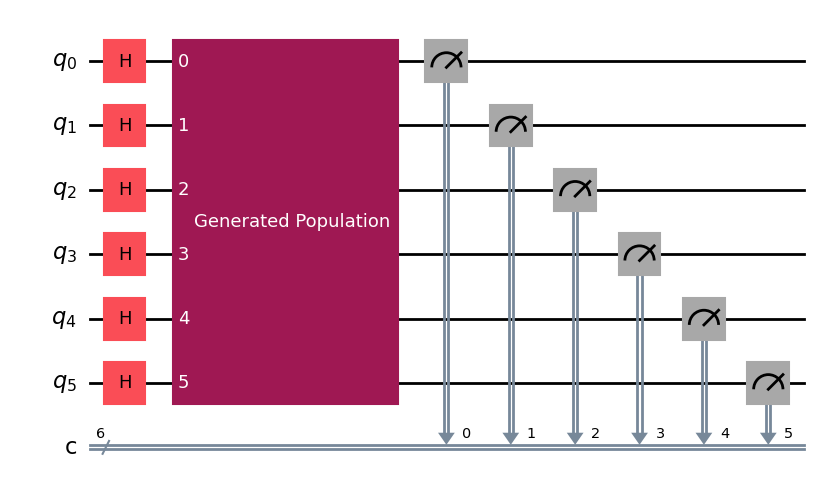

In [23]:
#Generated = False
BuildCircuit(n, ST, bcombine, not generated).draw(output='mpl')

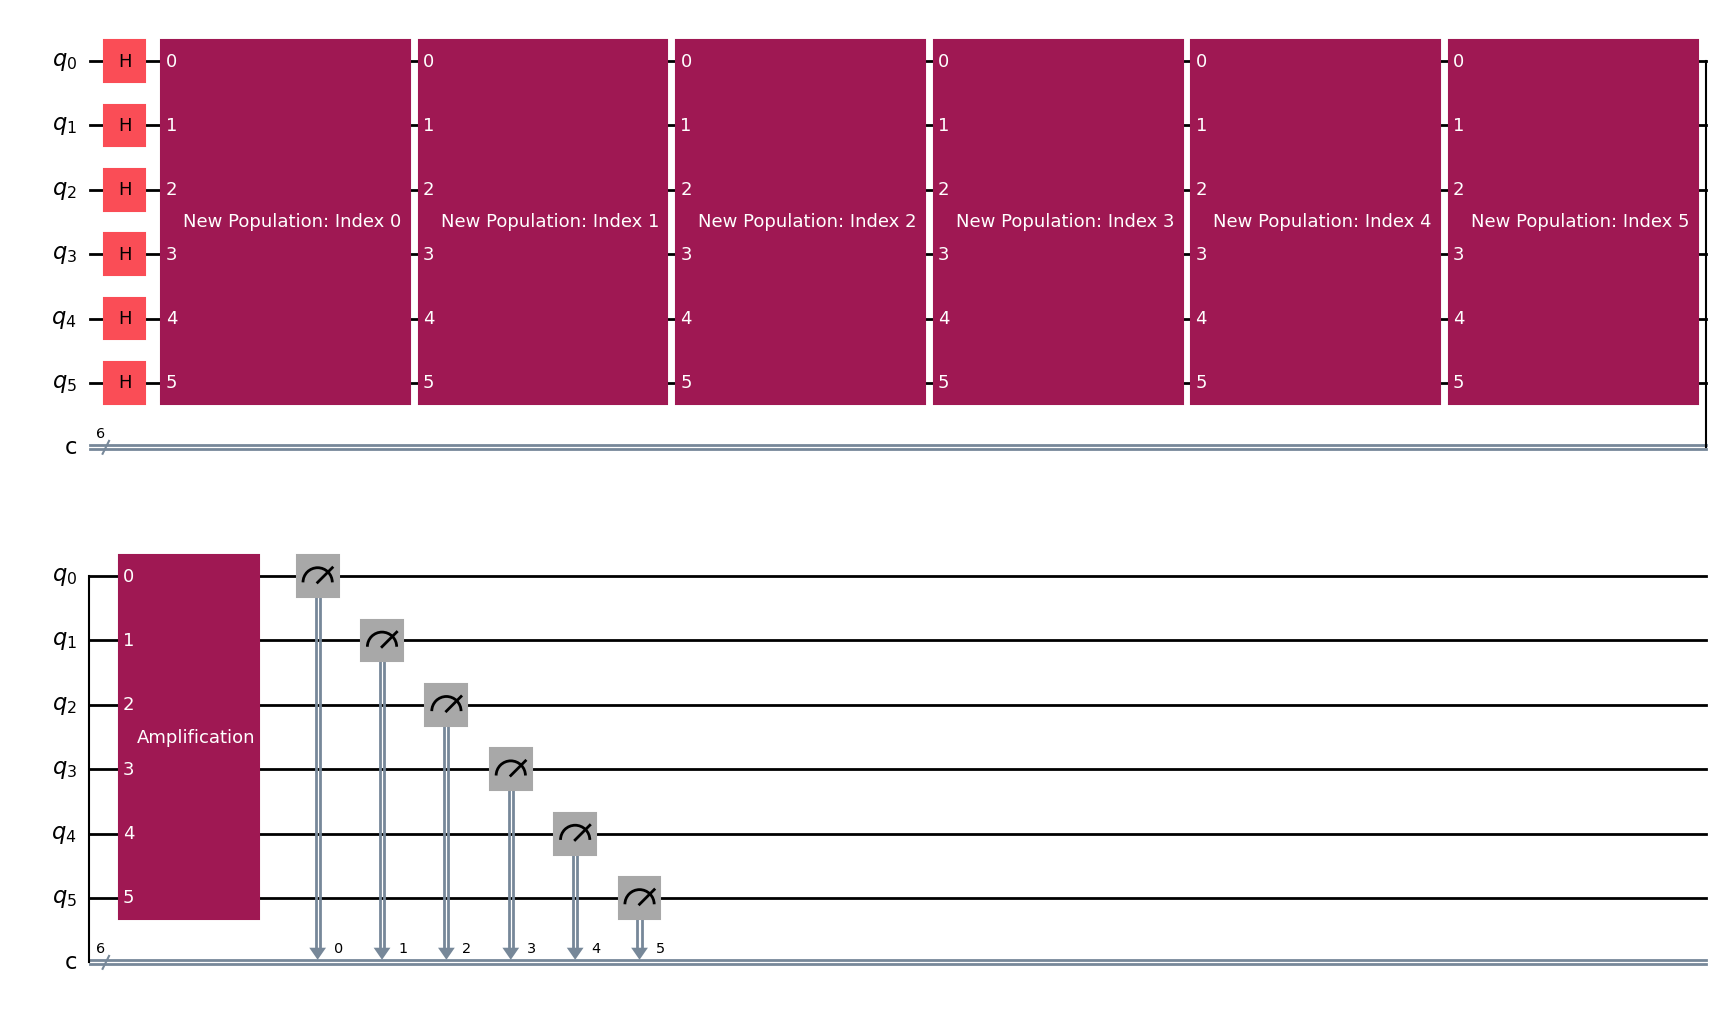

In [24]:
#Generated = True
BuildCircuit(n, ST, bcombine, generated).draw(output='mpl')
# new_circuit = transpile(qc, backend = backend)
# job = backend.run(new_circuit, shots = 1024)
# result = job.result()
# counts = result.get_counts()
# plot_histogram(counts)


In [ ]:
t = 0
Conditions = False
if os.path.exists("ResultsSimple.txt"):
    os.remove("ResultsSimple.txt")

backend = BasicProvider().get_backend("basic_simulator")

ST = n * [0.5]
qc = BuildCircuit(n, ST, bcombine, not generated) # QCircuit1

# WriteResults(0, n, bcombine, counts, PopulationAmount)
#plot_histogram(counts)

for x in range(maxGenerations):
#x = 0
#while True:
    new_circuit = transpile(qc, backend = backend)
    job = backend.run(new_circuit, shots = 10024)
    result = job.result()
    counts = result.get_counts()

    CS = WriteResults(x, n, bcombine, counts, PopulationAmount, ST)
    #x+=1
    BS, Conditions = CheckConditions(CS, n, SelectedAmount, benchmark)

    if Conditions:
        print("We found the best solution!")
        break

    # Probability vector
    ST = CreateProbabilityVector(n, SelectedAmount, BS)

    ST = ImproveDiversity(ST)

    #Build new circuit
    qc = BuildCircuit(n, ST, bcombine, generated) # QCircuit2




We found the best solution!
